In [96]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import os

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [98]:
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20
CHANNELS = 3

In [99]:
transform = torchvision.transforms.Compose([
      torchvision.transforms.RandomHorizontalFlip(p=0.5),  # Flip with probability 0.5
      torchvision.transforms.RandomVerticalFlip(p=0.5),    # Flip vertically with probability 0.5
      torchvision.transforms.RandomRotation(30),            # Rotate by up to 30 degrees
      torchvision.transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random crop
      torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color jitter
      torchvision.transforms.ToTensor(),                    # Convert to tensor
      torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalization
])

In [100]:
dataset_1 = torchvision.datasets.ImageFolder(os.path.join(main_path,training_path), transform = transform)
dataset_2 = torchvision.datasets.ImageFolder(os.path.join(main_path, testing_path), transform = transform)

In [101]:
dataset = torch.utils.data.ConcatDataset([dataset_1,dataset_2])

In [102]:
len(dataset)

7023

In [103]:
class_names = dataset_1.classes
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [104]:
# Split Dataset
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size , test_size])

In [105]:
len(train_dataset), len(val_dataset), len(test_dataset)

(4916, 1053, 1054)

In [106]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    pin_memory = True,
    persistent_workers = True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    pin_memory = True,
    persistent_workers = True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True,
    persistent_workers = True
)

In [107]:
len(train_loader), len(val_loader), len(test_loader)

(77, 17, 17)

In [108]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

def unnormalize(img_tensor, mean, std):
    img_tensor = img_tensor.clone()  # Clone the tensor to avoid modifying the original
    std = std.view(1,3,1,1) # N, C, H, W
    mean = mean.view(1,3,1,1)
    img_tensor = img_tensor * std + mean
    return img_tensor

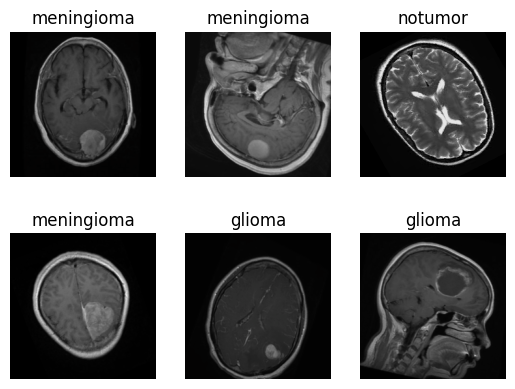

In [109]:
image, label = next(iter(train_loader))

for i in range(6):
    unnorm_img = unnormalize(image[i], mean, std)
    plt.subplot(2,3,i+1)
    plt.imshow(unnorm_img.squeeze().permute(1,2,0)) # C,H,W -> H,W,C
    plt.title(class_names[label[i]])
    plt.axis("off")

In [110]:
# load model
weights = torchvision.models.Wide_ResNet101_2_Weights.DEFAULT
base_model = torchvision.models.wide_resnet101_2(weights = weights)

In [111]:
# Freez layers
for param in base_model.parameters():
    param.requires_grad = False

In [112]:
!pip install torchinfo

In [113]:
from torchinfo import summary
summary(
    model = base_model,
    input_size = (BATCH_SIZE, CHANNELS, IMG_SIZE, IMG_SIZE),
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    col_width = 20,
    row_settings = ["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [64, 3, 224, 224]    [64, 1000]           --                   False
├─Conv2d (conv1)                         [64, 3, 224, 224]    [64, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [64, 64, 112, 112]   [64, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [64, 64, 112, 112]   [64, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [64, 64, 112, 112]   [64, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [64, 64, 56, 56]     [64, 256, 56, 56]    --                   False
│    └─Bottleneck (0)                    [64, 64, 56, 56]     [64, 256, 56, 56]    --                   False
│    │    └─Conv2d (conv1)               [64, 64, 56, 56]     [64, 128, 56, 56]    (8,192)              False
│    │    └─

In [114]:
# Unfreez last 15 layers
for param in list(base_model.parameters())[-15:]:
  param.requires_grad = True

In [115]:
base_model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [116]:
base_model.fc = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2),
    torch.nn.Linear(in_features = 2048, out_features = 1024),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.2),
    torch.nn.Linear(in_features = 1024, out_features = len(class_names))
)

In [117]:
summary(
    model = base_model,
    input_size = (BATCH_SIZE, CHANNELS, IMG_SIZE, IMG_SIZE),
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    col_width = 20,
    row_settings = ["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [64, 3, 224, 224]    [64, 4]              --                   Partial
├─Conv2d (conv1)                         [64, 3, 224, 224]    [64, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [64, 64, 112, 112]   [64, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [64, 64, 112, 112]   [64, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [64, 64, 112, 112]   [64, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [64, 64, 56, 56]     [64, 256, 56, 56]    --                   False
│    └─Bottleneck (0)                    [64, 64, 56, 56]     [64, 256, 56, 56]    --                   False
│    │    └─Conv2d (conv1)               [64, 64, 56, 56]     [64, 128, 56, 56]    (8,192)              False
│    │    

In [118]:
# Loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p : p.requires_grad, base_model.parameters()), lr = 0.001)

In [119]:
# learning rate scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = 0.1,
    patience = 3,
    cooldown = 0,
    min_lr = 0.00001,
)

# Early stopping
best_val_loss = float("inf")
patience = 5
patience_counter = 0

In [120]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = base_model
model.to(device)

history = {
     "train_loss" : [],
     "train_acc" : [],
     "val_loss" : [],
     "val_acc" : []
 }

prev_lr = optimizer.param_groups[0]['lr']

In [121]:
# Training

for epoch in tqdm(range(EPOCHS)):

    # train_mode
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    # Iterate over batches
    for batch, (x_train,y_train) in enumerate(tqdm(train_loader)):
        x_train, y_train = x_train.to(device), y_train.to(device)

        # Forward pass
        y_preds = model(x_train)

        # Compute loss
        loss = criterion(y_preds, y_train)
        train_loss += loss.item()

        # Zero gradients
        optimizer.zero_grad()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # calculate accuracy
        y_pred_class = torch.argmax(torch.softmax(y_preds, dim = 1), dim = 1)
        train_acc += (y_pred_class == y_train).sum().item() / len(y_preds)

    train_loss = train_loss / len(train_loader)
    train_acc = train_acc / len(train_loader)

    # val mode
    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)

            # forward
            val_preds = model(x_val)

            # loss
            loss = criterion(val_preds, y_val)
            val_loss += loss.item()

            val_pred_labels = val_preds.argmax(dim = 1)
            val_acc += (val_pred_labels == y_val).sum().item() / len(val_pred_labels)

    val_loss = val_loss / len(val_loader)
    val_acc = val_acc / len(val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history["val_acc"].append(val_acc)

    # learning rate scheduler
    lr_scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    if current_lr != prev_lr:
        print(f"Learning rate changed from {prev_lr} to {current_lr}")
        prev_lr = current_lr

    # check early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print(f"New best model found at epoch {epoch+1}")
        torch.save(model.state_dict(), "best_model.pth")

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    # print
    print(f"\nEpoch: {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | learning rate: {current_lr:.5f}\n")

# Best Model Load
model.load_state_dict(torch.load('best_model.pth'))

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

New best model found at epoch 1

Epoch: 1/20 | Train Loss: 0.4353 | Train Acc: 0.8336 | Val Loss: 0.4135 | Val Acc: 0.8641 | learning rate: 0.00100



  0%|          | 0/77 [00:00<?, ?it/s]

New best model found at epoch 2

Epoch: 2/20 | Train Loss: 0.2442 | Train Acc: 0.9062 | Val Loss: 0.3029 | Val Acc: 0.9022 | learning rate: 0.00100



...

Learning rate changed from 0.001 to 0.0001

Epoch: 17/20 | Train Loss: 0.0621 | Train Acc: 0.9750 | Val Loss: 0.1312 | Val Acc: 0.9573 | learning rate: 0.00010



  0%|          | 0/77 [00:00<?, ?it/s]

Early stopping at epoch 18


<ipython-input-121-9adf3979a3b8>:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


<All keys matched successfully>

In [122]:
def evaluate(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    with torch.no_grad():
        for batch, (image, label) in enumerate(tqdm(data_loader)):
            image, label = image.to(device), label.to(device)

            preds = model(image)

            loss = loss_fn(preds, label)
            total_loss += loss.item()

            pred_labels = preds.argmax(dim = 1)
            total_acc += (pred_labels == label).sum().item() / len(pred_labels)

    total_loss /= len(data_loader)
    total_acc /= len(data_loader)

    print(f"Loss: {total_loss:.4f} | Accuracy: {total_acc:.4f}")

In [123]:
evaluate(model, test_loader, criterion)

  0%|          | 0/17 [00:00<?, ?it/s]

Loss: 0.1515 | Accuracy: 0.9513


In [124]:
# Classification reports and confusion matrix
y_pred = []
y_true = []

with torch.no_grad():
    for image, label in tqdm(test_loader):
        image, label = image.to(device), label.to(device)

        output = model(image)
        _, preds = torch.max(output.data, 1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(label.cpu().numpy())


  0%|          | 0/17 [00:00<?, ?it/s]

In [129]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names = class_names))

              precision    recall  f1-score   support

      glioma       0.96      0.92      0.94       240
  meningioma       0.88      0.94      0.91       253
     notumor       0.99      0.99      0.99       297
   pituitary       0.98      0.95      0.97       264

    accuracy                           0.95      1054
   macro avg       0.95      0.95      0.95      1054
weighted avg       0.95      0.95      0.95      1054



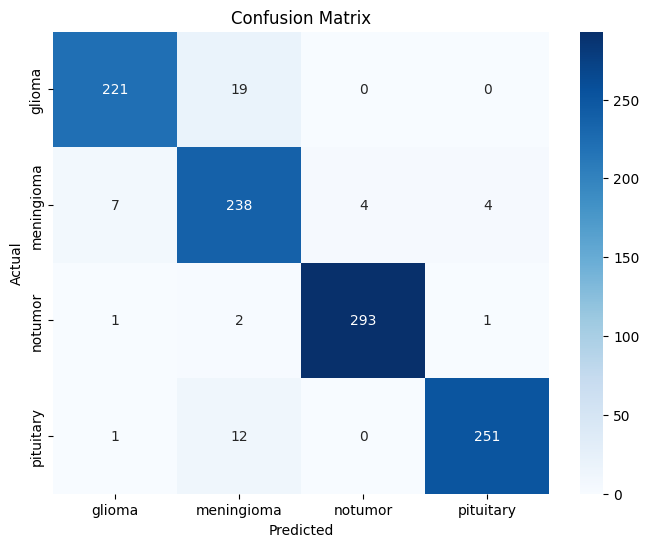

In [131]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

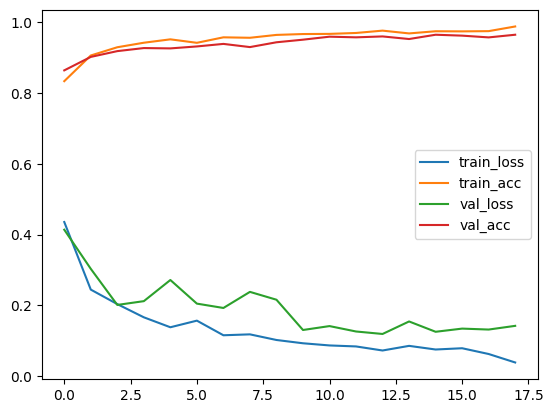

In [132]:
import pandas as pd
pd.DataFrame(history).plot()
plt.show()

In [133]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize an image tensor
def unnormalize(img, mean, std):
    mean = mean[None, None, :]  # Reshape mean and std for broadcasting
    std = std[None, None, :]
    img = img * std + mean  # Unnormalize
    return img

# Mean and std for unnormalizing
unnormalized_mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

def prediction(num=6, model=None, test_loader=None, class_names=None, device='cpu'):
    model.eval()  # Set the model to evaluation mode
    plt.figure(figsize=(15,15))

    with torch.no_grad():  # Disable gradient computation for faster inference
        for images, labels in test_loader:  # Get one batch of images and labels
            images, labels = images.to(device), labels.to(device)
            batch_predictions = model(images)

            for i in range(num):
                # Unnormalize the image before converting it to NumPy
                img = images[i].cpu().numpy().transpose((1, 2, 0))  # Convert from torch.Tensor to numpy
                img = unnormalize(img, unnormalized_mean.numpy(), std.numpy())  # Unnormalize the image
                img = np.clip(img, 0, 1)
                img = (img * 255).astype('uint8')  # Rescale image to [0, 255]

                label = labels[i].cpu().item()

                ax = plt.subplot(3, 3, i+1)
                plt.imshow(img)
                actual_label = class_names[label]

                predicted_label_idx = torch.argmax(batch_predictions[i]).item()
                predicted_label = class_names[predicted_label_idx]
                confidence = round(100 * torch.softmax(batch_predictions[i], dim=0)[predicted_label_idx].item(), 2)

                plt.title(f"Actual Label : {actual_label} \n Predicted Label : {predicted_label} \n Confidence : {confidence}%")
                plt.axis("off")

            break

    plt.show()

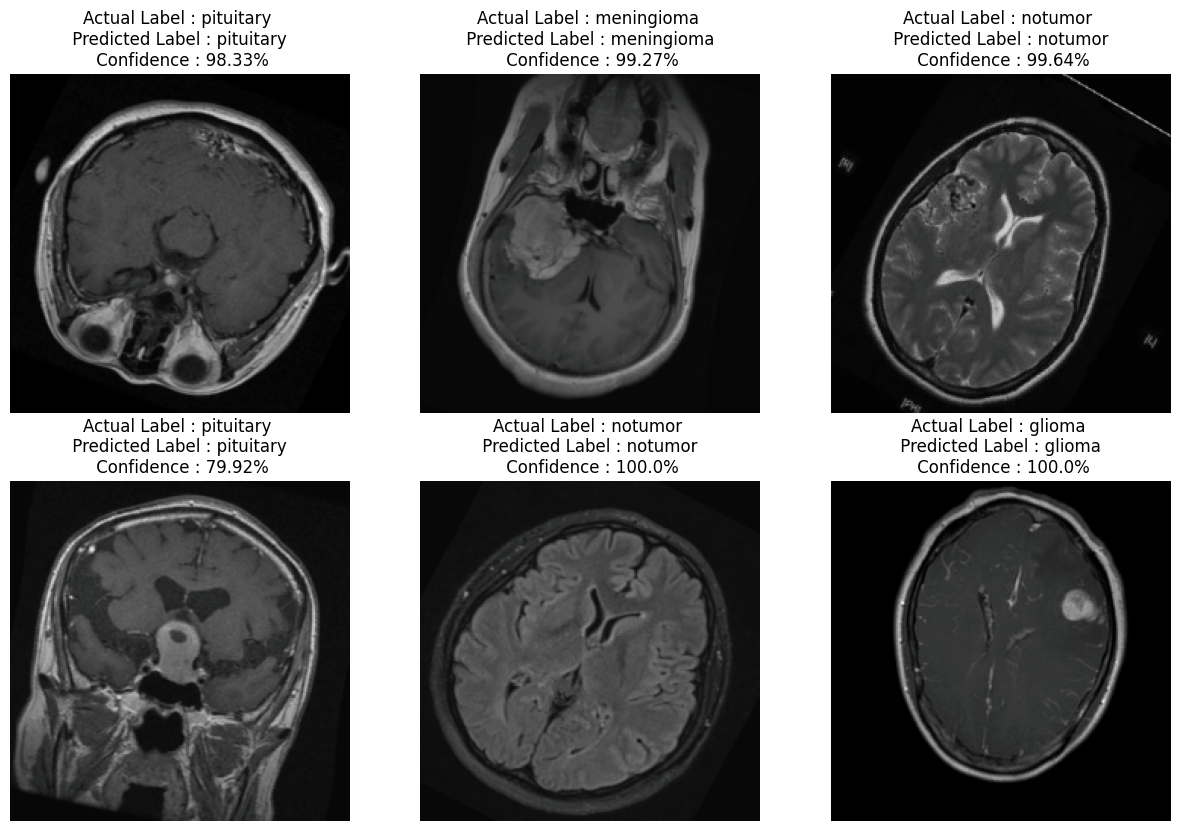

In [134]:
prediction(model=model, test_loader=test_loader, class_names=class_names, device=device)


In [135]:
torch.save(model.state_dict(), "/content/drive/MyDrive/final_model.pth")